In [15]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [16]:
df = pd.read_csv("src/data/lenguaspaises.csv")

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2810 entries, 0 to 2809
Data columns (total 27 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ID                    2810 non-null   int64  
 1   Name_English          2810 non-null   object 
 2   Countries             2810 non-null   object 
 3   Degree_endangerment   2810 non-null   object 
 4   Number_speakers       2810 non-null   float64
 5   Description_location  1998 non-null   object 
 6   endangerment_score    2810 non-null   int64  
 7   Countries_list        2810 non-null   object 
 8   Region                2801 non-null   object 
 9   Population            2801 non-null   float64
 10  Area_sq_mi            2801 non-null   float64
 11  Pop_density           2801 non-null   float64
 12  Coastline             2801 non-null   float64
 13  Migration             2801 non-null   float64
 14  Infant_mortality      2801 non-null   float64
 15  GDP                  

# H2: Hablantes y nivel de peligro de desaparición
Hipótesis: **Las lenguas con más hablantes tienen un menor riesgo de desaparecer.**  
Evaluaremos esta hipótesis con el **coeficiente de correlación de Spearman** ya que mide la relación monótona entre dos variables sin exigir normalidad, sin asumir linealidad y funciona con variables ordinales como nuestro endangerment_score. 
*Evaluación de los resultados*:
-	Si al aumentar una variable, la otra tiende a disminuir, ρ será negativo.
-	Si ambas crecen juntas, ρ será positivo.
-	Si no hay patrón monótono, ρ estará cerca de 0.


In [18]:
from scipy.stats import spearmanr

In [19]:
# Filtrar filas válidas
df_corr = df[['Number_speakers', 'endangerment_score']].dropna()

# Calcular Spearman
rho, pval = spearmanr(df_corr['Number_speakers'], df_corr['endangerment_score'])

print(f"Spearman rho: {rho:.3f}")
print(f"p-value: {pval:.3e}")

Spearman rho: -0.699
p-value: 0.000e+00


## Resultados e interpetación  

**Spearman** rho: -0.699  
**p-value**: 0.000e+00  

El valor de la correlación de Spearman (-0.699) indica que las lenguas con más hablantes tienden a presentar niveles más bajos de amenaza.  

El p-value asociado muy cercano al 0 confirma que se trata de una erlación estadísticamente significativa, es decir, altamente improbable en el caso de hipótoesis nula de ausencia de asociación.


### H2. VISUALIZACIÓN
La relación entre número de hablantes y grado de peligro se visualiza de forma clara mediante un scatterplot con escala logarítmica en el eje de hablantes. La nube de puntos muestra una tendencia monótona decreciente, que confirma la correlación negativa observada en el análisis de Spearman.

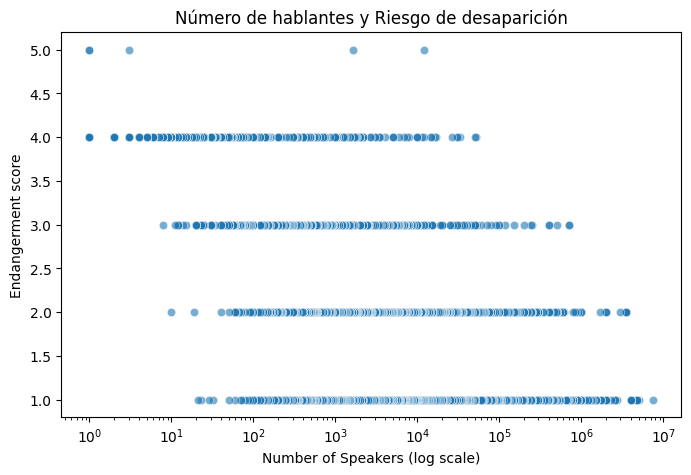

In [20]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df,
    x='Number_speakers',
    y='endangerment_score',
    alpha=0.6
)

plt.xscale('log')
plt.xlabel('Number of Speakers (log scale)')
plt.ylabel('Endangerment score')
plt.title('Número de hablantes y Riesgo de desaparición')

plt.savefig("src/img/H2.png")
plt.show()

# H6: Densidad de población y número de lenguas en riesgo de desaparición
Hipótesis: **Los países más densamente poblados no tienen necesariamente más lenguas en peligro.**  

La densidad poblacional no correlaciona con el número de lenguas amenazadas por país.  

Para evaluar esta hipótesis usaremos la correlación de **Pearson** analiza la correlación lineal entre dos variables numéricas. Number of speakers y, recordemos que endangerment degree ha sido cuantificada en la variable numérica endangerment_score.

Antes de calcular el coeficiente de correlación de Pearson vemos que la columna de densidad de población tiene 9 filas sin datos.
- 1 se corresponde al Romaní hablado en Montenegro
- 4 son lenguas habladas en Costa de Marfil
- Y las cuatro restantes se corresponden con lenguas habladas en los países: Niue, Tokelau, Norfolk Island(Australia), Pitcarin(UK)
Asignaremos los datos de densidad de población de Montenegro y Costa de Marfil ya que contamos con valores oficiales


In [21]:
df[df['Pop_density'].isna()== True]

,ID,Name_English,Countries,Degree_endangerment,Number_speakers,Description_location,endangerment_score,Countries_list,Region,Population,...,Phones,Arable,Crops,Other,Climate,Birthrate,Deathrate,Agriculture,Industry,Service
43,405,Romani,"Albania, Germany, Austria, Belarus, Bosnia and...",Definitely endangered,3500000.0,"many European countries, most densely in East-...",2,Montenegro,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
626,703,Niuean,Niue,Definitely endangered,14000.0,"1260 on Niue, remainder mostly in New Zealand",2,Niue,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
946,713,Tokelauan,Tokelau,Severely endangered,4500.0,Tokelau and New Zealand,3,Tokelau,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1275,15,Jeri,Côte d'Ivoire,Severely endangered,1500.0,NaN,3,Ivory Coast,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1385,1320,Ega,Côte d'Ivoire,Severely endangered,1000.0,NaN,3,Ivory Coast,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1574,715,Norfolk-Pitcairn (Norfolk),Norfolk Island (Australia),Definitely endangered,580.0,Norfolk Island,2,Norfolk Island (Australia),NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2169,2622,Norfolk-Pitcairn (Pitcairn),Pitcairn (U.K.),Vulnerable,50.0,Pitcairn Island,1,Pitcairn (U.K.),NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2616,1321,Eotile,Côte d'Ivoire,Extinct,0.0,NaN,5,Ivory Coast,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2774,16,Tonjon,Côte d'Ivoire,Extinct,0.0,NaN,5,Ivory Coast,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [22]:
''' 
Reemplazamos los datos por la densidad de población de estos países
Montenegro: 46.0
Costa de Marfil 98.0
'''
df.loc[df['Countries_list'] == "Ivory Coast", 'Pop_density'] = 98.0
df.loc[df['Countries_list'] == "Montenegro", 'Pop_density'] = 46.0

In [23]:
df = df.dropna(subset=['Pop_density'])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2806 entries, 0 to 2809
Data columns (total 27 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ID                    2806 non-null   int64  
 1   Name_English          2806 non-null   object 
 2   Countries             2806 non-null   object 
 3   Degree_endangerment   2806 non-null   object 
 4   Number_speakers       2806 non-null   float64
 5   Description_location  1994 non-null   object 
 6   endangerment_score    2806 non-null   int64  
 7   Countries_list        2806 non-null   object 
 8   Region                2801 non-null   object 
 9   Population            2801 non-null   float64
 10  Area_sq_mi            2801 non-null   float64
 11  Pop_density           2806 non-null   float64
 12  Coastline             2801 non-null   float64
 13  Migration             2801 non-null   float64
 14  Infant_mortality      2801 non-null   float64
 15  GDP                   2801

In [24]:
df_country_counts = df.groupby("Countries_list")["Name_English"].count().reset_index()
df_country_counts.rename(columns={"Name_English": "num_endangered_languages"}, inplace=True)
df_country_counts.head()

,Countries_list,num_endangered_languages
0,Afghanistan,21
1,Albania,3
2,Algeria,10
3,Angola,4
4,Argentina,16


In [25]:
df_final = df.merge(df_country_counts, on="Countries_list", how="left")
df_final.head()

,ID,Name_English,Countries,Degree_endangerment,Number_speakers,Description_location,endangerment_score,Countries_list,Region,Population,...,Arable,Crops,Other,Climate,Birthrate,Deathrate,Agriculture,Industry,Service,num_endangered_languages
0,1022,South Italian,Italy,Vulnerable,7500000.0,"Campania, Lucania (Basilicata), Abruzzi (Abruz...",1,Italy,WESTERN EUROPE,58133509.0,...,27.79,9.53,62.68,NaN,8.72,10.40,0.021,0.291,0.688,29
1,1023,Sicilian,Italy,Vulnerable,5000000.0,"Sicily (Sicilia), southern and central Calabri...",1,Italy,WESTERN EUROPE,58133509.0,...,27.79,9.53,62.68,NaN,8.72,10.40,0.021,0.291,0.688,29
2,383,Low Saxon,"Germany, Denmark, Netherlands, Poland, Russian...",Vulnerable,4800000.0,"northern Germany, the north-eastern part of th...",1,Germany,WESTERN EUROPE,82422299.0,...,33.85,0.59,65.56,3.0,8.25,10.62,0.009,0.296,0.695,8
3,383,Low Saxon,"Germany, Denmark, Netherlands, Poland, Russian...",Vulnerable,4800000.0,"northern Germany, the north-eastern part of th...",1,Denmark,WESTERN EUROPE,5450661.0,...,54.02,0.19,45.79,3.0,11.13,10.36,0.018,0.246,0.735,1
4,383,Low Saxon,"Germany, Denmark, Netherlands, Poland, Russian...",Vulnerable,4800000.0,"northern Germany, the north-eastern part of th...",1,Netherlands,WESTERN EUROPE,16491461.0,...,26.71,0.97,72.32,3.0,10.90,8.68,0.021,0.244,0.736,5


In [26]:
from scipy.stats import pearsonr

r, p_value = pearsonr(df_final['Pop_density'], df_final['endangerment_score'])

print("Coeficiente de Pearson:", r)
print("p-valor:", p_value)

Coeficiente de Pearson: -0.05867766312189542
p-valor: 0.00187372915347643


## Resultados e interpetación 

**Coeficiente de Pearson:** −0.0587
**p‑valor:** 0.00187  
No hay relación lineal entre la densidad de población y número de lenguas en peligro.  

Aunque el p‑valor asociado (p = 0.0019) es estadísticamente significativo debido al tamaño de la muestra, la magnitud del coeficiente es extremadamente baja, por lo que la relación carece de importancia práctica.  

Estos resultados apoyan la hipótesis planteada: los países más densamente poblados no presentan necesariamente un mayor número de lenguas en peligro.

### H6. VISUALIZACIÓN

El análisis de Pearson muestra que no existe una relación monótona entre la densidad de población y el número de lenguas amenazadas por país (ρ ≈ 0, p > 0.05). Esto indica que los países más densamente poblados no presentan necesariamente un mayor número de lenguas en peligro, lo que respalda la hipótesis planteada.”

In [27]:
df_final.head()

,ID,Name_English,Countries,Degree_endangerment,Number_speakers,Description_location,endangerment_score,Countries_list,Region,Population,...,Arable,Crops,Other,Climate,Birthrate,Deathrate,Agriculture,Industry,Service,num_endangered_languages
0,1022,South Italian,Italy,Vulnerable,7500000.0,"Campania, Lucania (Basilicata), Abruzzi (Abruz...",1,Italy,WESTERN EUROPE,58133509.0,...,27.79,9.53,62.68,NaN,8.72,10.40,0.021,0.291,0.688,29
1,1023,Sicilian,Italy,Vulnerable,5000000.0,"Sicily (Sicilia), southern and central Calabri...",1,Italy,WESTERN EUROPE,58133509.0,...,27.79,9.53,62.68,NaN,8.72,10.40,0.021,0.291,0.688,29
2,383,Low Saxon,"Germany, Denmark, Netherlands, Poland, Russian...",Vulnerable,4800000.0,"northern Germany, the north-eastern part of th...",1,Germany,WESTERN EUROPE,82422299.0,...,33.85,0.59,65.56,3.0,8.25,10.62,0.009,0.296,0.695,8
3,383,Low Saxon,"Germany, Denmark, Netherlands, Poland, Russian...",Vulnerable,4800000.0,"northern Germany, the north-eastern part of th...",1,Denmark,WESTERN EUROPE,5450661.0,...,54.02,0.19,45.79,3.0,11.13,10.36,0.018,0.246,0.735,1
4,383,Low Saxon,"Germany, Denmark, Netherlands, Poland, Russian...",Vulnerable,4800000.0,"northern Germany, the north-eastern part of th...",1,Netherlands,WESTERN EUROPE,16491461.0,...,26.71,0.97,72.32,3.0,10.90,8.68,0.021,0.244,0.736,5


Claramente no hay una distribución lineal entre la densidad de población. Vemos claramente el outlier que como se puede observar en el siguiente gráfico corresponde a Europa Occidental

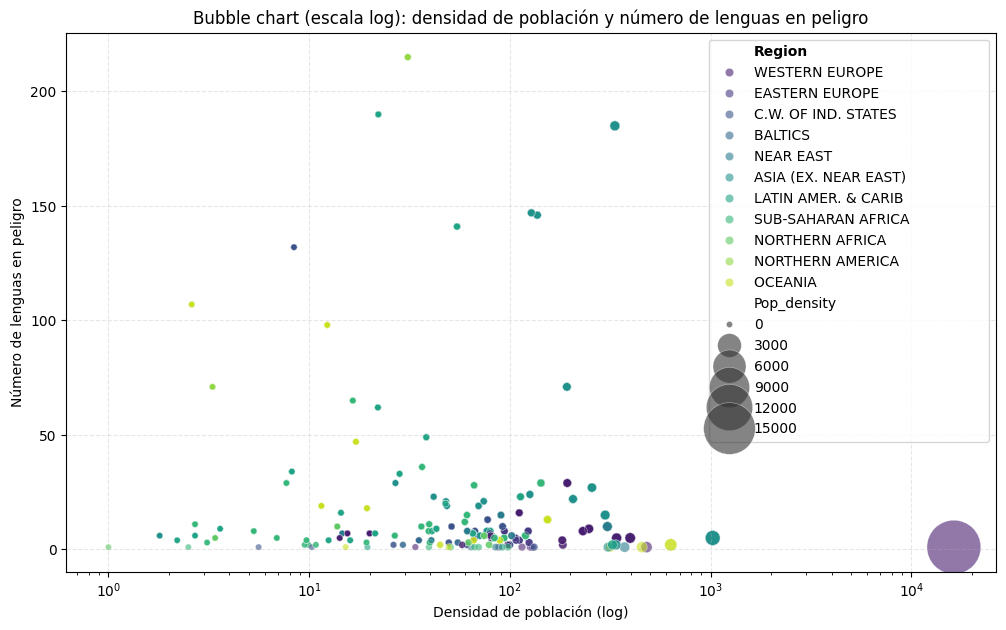

In [28]:
plt.figure(figsize=(12,7))
# el tamaño de las burbujas es en función de la población total y no por la densidad
sns.scatterplot(
    data=df_final,
    x="Pop_density",
    y="num_endangered_languages",
    size="Pop_density",
    sizes=(20, 1500),   
    hue="Region",
    alpha=0.6,
    palette="viridis"
)

# aplicar escala logarítmica en el eje de densidad de población para mejorar la visualización
plt.xscale("log")
plt.title("Bubble chart (escala log): densidad de población y número de lenguas en peligro")
plt.xlabel("Densidad de población (log)")
plt.ylabel("Número de lenguas en peligro")
plt.grid(True, linestyle="--", alpha=0.3)
legend = plt.gca().get_legend()
legend.get_title().set_fontweight('bold')
# Poner en negrita Region y Population dentro de la leyenda
for text in legend.texts:
    if "Region" in text.get_text() or "Population" in text.get_text():
        text.set_fontweight('bold')
plt.savefig("src/img/H6.png")
plt.show()


Claramente se ve una ausencia total de relación lineal. También se puede apreciar claramente el outlier de Europa Occidental